<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Assignment_3_Time_Series_Forecasting_in_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# BILAL-Assignment 3: Time Series Forecasting in Machine Learning
# Data Ingestion & Exploration
# Uploading and Extract Dataset
# Upload file from local system
from google.colab import files
uploaded = files.upload()

Saving household_power_consumption.zip to household_power_consumption.zip


In [2]:
# Extracting ZIP File
import zipfile
import os

zip_path = "household_power_consumption.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

print("Files extracted successfully!")
print(os.listdir("/content/"))

Files extracted successfully!
['.config', 'household_power_consumption.txt', 'household_power_consumption.zip', 'sample_data']


In [3]:
# Loading Dataset
import pandas as pd

file_path = "/content/household_power_consumption.txt"

df = pd.read_csv(
    file_path,
    sep=';',
    parse_dates={'Datetime': ['Date', 'Time']},
    infer_datetime_format=True,
    na_values='?',
    low_memory=False
)

df.head()

/tmp/ipython-input-151/2809069926.py:6: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
/tmp/ipython-input-151/2809069926.py:6: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(
/tmp/ipython-input-151/2809069926.py:6: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
# Basic Info & Missing Values
print(df.info())
print("\nMissing Values:\n")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Datetime               datetime64[ns]
 1   Global_active_power    float64       
 2   Global_reactive_power  float64       
 3   Voltage                float64       
 4   Global_intensity       float64       
 5   Sub_metering_1         float64       
 6   Sub_metering_2         float64       
 7   Sub_metering_3         float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 126.7 MB
None

Missing Values:

Datetime                     0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [5]:
# Convertting to Numeric
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')
df = df.dropna(subset=['Global_active_power'])

In [6]:
# Setting Datetime Index
df = df.set_index('Datetime')
df = df.sort_index()
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


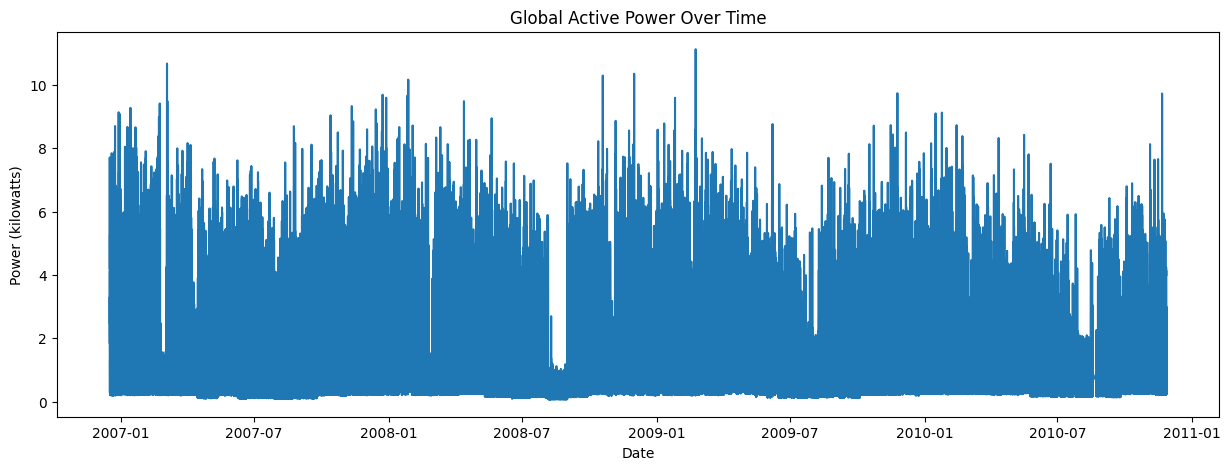

In [7]:
# Exploratory Data Analysis (EDA)
# Line Plot (Time Trend)
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df['Global_active_power'])
plt.title("Global Active Power Over Time")
plt.xlabel("Date")
plt.ylabel("Power (kilowatts)")
plt.show()

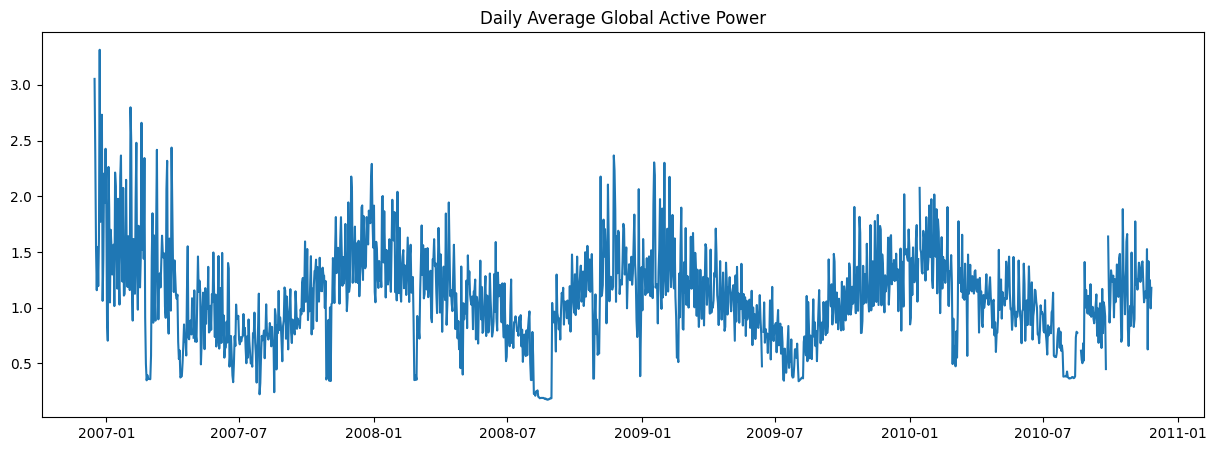

In [9]:
# Resampling to Daily Average
daily_power = df['Global_active_power'].resample('D').mean()

plt.figure(figsize=(15,5))
plt.plot(daily_power)
plt.title("Daily Average Global Active Power")
plt.show()

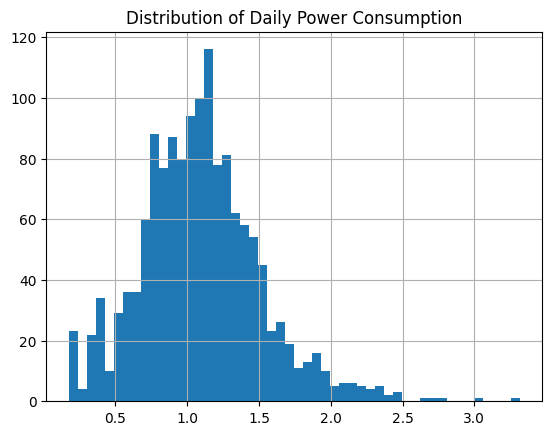

In [10]:
# Distribution Plot
daily_power.hist(bins=50)
plt.title("Distribution of Daily Power Consumption")
plt.show()

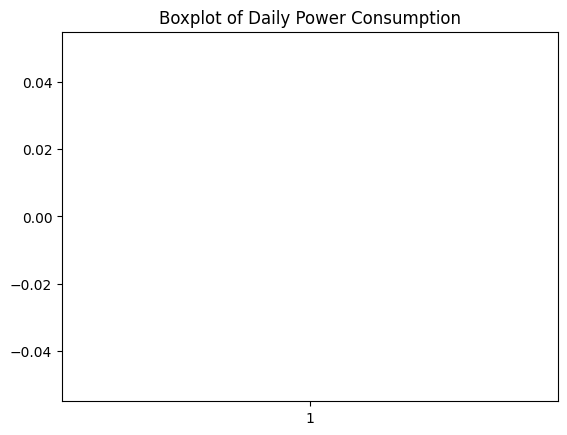

In [11]:
# Boxplot (Detectign Outliers)
plt.boxplot(daily_power)
plt.title("Boxplot of Daily Power Consumption")
plt.show()

In [12]:
# Data Preprocessing & Feature Engineering
# Handling Missing Values
daily_power = daily_power.fillna(method='ffill')

/tmp/ipython-input-151/3209402273.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_power = daily_power.fillna(method='ffill')


In [13]:
# Creating Lag Features
data = pd.DataFrame(daily_power)
data['lag_1'] = data['Global_active_power'].shift(1)
data['lag_7'] = data['Global_active_power'].shift(7)
data['rolling_mean_7'] = data['Global_active_power'].rolling(7).mean()

data = data.dropna()
data.head()

,Global_active_power,lag_1,lag_7,rolling_mean_7
Datetime,,,,
2006-12-23,3.314851,1.625929,3.053475,1.817457
2006-12-24,1.770842,3.314851,2.354486,1.734079
2006-12-25,1.904944,1.770842,1.530435,1.787580
2006-12-26,2.732021,1.904944,1.157079,2.012572
2006-12-27,1.061639,2.732021,1.545658,1.943426


In [15]:
# Train-Test Split -Time Based
# Splitting Data
train_size = int(len(data) * 0.8)

train = data[:train_size]
test = data[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 1148
Test size: 287


In [16]:
# Model 1 – ARIMA
# Building the ARIMA Model
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train['Global_active_power'], order=(5,1,0))
arima_result = arima_model.fit()

arima_forecast = arima_result.forecast(steps=len(test))

In [17]:
# ARIMA Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_arima = mean_absolute_error(test['Global_active_power'], arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test['Global_active_power'], arima_forecast))

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)

ARIMA MAE: 0.3612782062474506
ARIMA RMSE: 0.44069122767094226


In [18]:
# Random Forest -ML Model
# Preparing the Features
X_train = train[['lag_1', 'lag_7', 'rolling_mean_7']]
y_train = train['Global_active_power']

X_test = test[['lag_1', 'lag_7', 'rolling_mean_7']]
y_test = test['Global_active_power']

In [19]:
# Training Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [21]:
# Random Forest Evaluation
mae_rf = mean_absolute_error(y_test, rf_predictions)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 0.16316070535006905
Random Forest RMSE: 0.22124543957240292


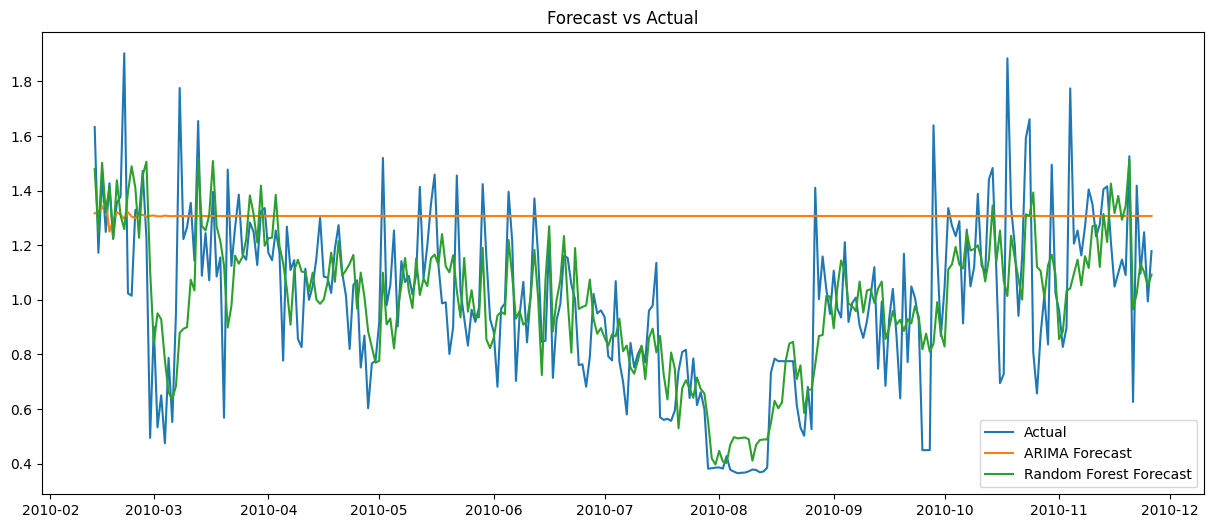

In [22]:
# Forecast Visualization
# Ploting the Predictions vs Actual
plt.figure(figsize=(15,6))

plt.plot(test.index, y_test, label='Actual')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.plot(test.index, rf_predictions, label='Random Forest Forecast')

plt.legend()
plt.title("Forecast vs Actual")
plt.show()

In [24]:
# Error Comparison
# Compare Models
print("Model Comparison")
print("------------------")
print("ARIMA RMSE:", rmse_arima)
print("Random Forest RMSE:", rmse_rf)

Model Comparison
------------------
ARIMA RMSE: 0.44069122767094226
Random Forest RMSE: 0.22124543957240292


Interpretation & Analysis
Key Insights:-
•	Daily power consumption shows clear fluctuations.
•	Some seasonal weekly patterns observed.
•	Random Forest captured nonlinear patterns better.
•	ARIMA performed reasonably but struggled with sudden spikes.
•	Feature engineering (lag & rolling mean) improved ML performance.
